# Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

# Data Collection and Processing

In [5]:
# Loading the dataset to pandas Data Frame 
loan_dataset = pd.read_csv('Load_Dataset.csv')

In [6]:
type(loan_dataset)

pandas.core.frame.DataFrame

# Printing the first 5 rows of the dataset

In [7]:
loan_dataset.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
# Numbers of rows and columns
loan_dataset.shape

(614, 13)

# Statistical measures

In [9]:
loan_dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [10]:
# Numbers of missing values in each column 
loan_dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

# Dropping thee missing values 

In [11]:
loan_dataset = load_dataset.dropna()

In [12]:
# Numbers of missing values in each column 
loan_dataset.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

# Label encoding :-

In [13]:
load_dataset.replace({"Loan_Status":{"N":0, "Y":1}}, inplace=True)

C:\Users\vaiks\AppData\Local\Temp\ipykernel_22872\2514377193.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  load_dataset.replace({"Loan_Status":{"N":0, "Y":1}}, inplace=True)


In [14]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [15]:
loan_dataset['Dependents'].value_counts()

Dependents
0     274
2      85
1      80
3+     41
Name: count, dtype: int64

In [16]:
# Replacing the value of 3+ to 4
loan_dataset = loan_dataset.replace(to_replace='3+', value=4)

In [17]:
# dependent values
loan_dataset['Dependents'].value_counts()

Dependents
0    274
2     85
1     80
4     41
Name: count, dtype: int64

<Axes: xlabel='Education', ylabel='count'>

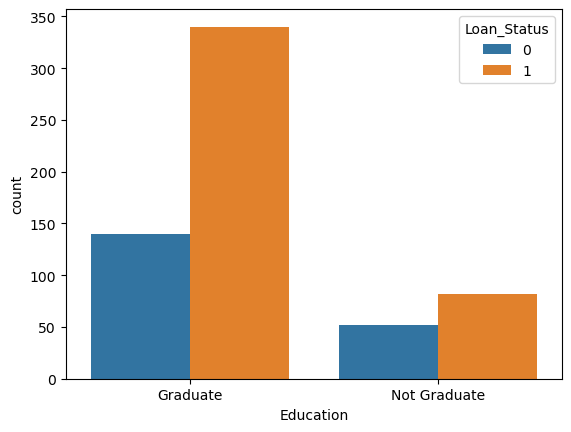

In [21]:
# Education & Loan status 
sns.countplot(x='Education', hue='Loan_Status', data=load_dataset)

<Axes: xlabel='Married', ylabel='count'>

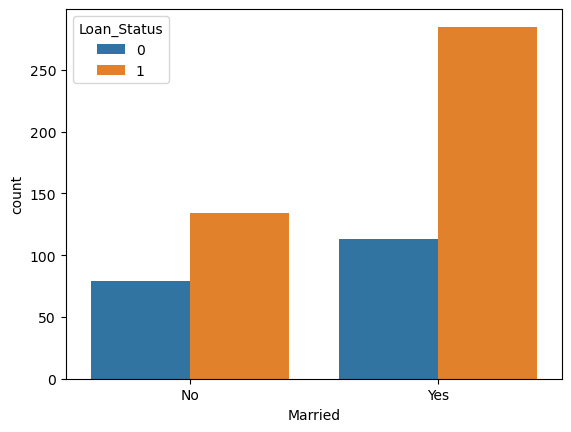

In [23]:
# Marital & Loan status
sns.countplot(x='Married', hue='Loan_Status', data=load_dataset)

In [25]:
# Convert Categroical column to numerical values
load_dataset.replace({'Married':{'No':0, 'Yes':1}, 'Gender':{'Male':1, 'Female':0}, 'Self_Employed':{'No':0, 'Yes':1}, 
                     'Property_Area':{'Rural':0, 'Semiurban':1, 'Urban':2}, 'Education':{'Graduate':1, 'Not Graduate':0}}, inplace=True)

C:\Users\vaiks\AppData\Local\Temp\ipykernel_22872\3394198334.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  load_dataset.replace({'Married':{'No':0, 'Yes':1}, 'Gender':{'Male':1, 'Female':0}, 'Self_Employed':{'No':0, 'Yes':1},


In [26]:
load_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1.0,0.0,0,1,0.0,5849,0.0,NaN,360.0,1.0,2,1
1,LP001003,1.0,1.0,1,1,0.0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1.0,1.0,0,1,1.0,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1.0,1.0,0,0,0.0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1.0,0.0,0,1,0.0,6000,0.0,141.0,360.0,1.0,2,1


In [30]:
# Seprating the data and label
X = loan_dataset.drop(columns=['Loan_ID', 'Loan_Status'], axis=1)
y = loan_dataset['Loan_Status']

In [29]:
print(X)
print(Y)

     Gender Married Dependents     Education  ... LoanAmount  Loan_Amount_Term  Credit_History  Property_Area
1      Male     Yes          1      Graduate  ...      128.0             360.0             1.0          Rural
2      Male     Yes          0      Graduate  ...       66.0             360.0             1.0          Urban
3      Male     Yes          0  Not Graduate  ...      120.0             360.0             1.0          Urban
4      Male      No          0      Graduate  ...      141.0             360.0             1.0          Urban
5      Male     Yes          2      Graduate  ...      267.0             360.0             1.0          Urban
..      ...     ...        ...           ...  ...        ...               ...             ...            ...
609  Female      No          0      Graduate  ...       71.0             360.0             1.0          Rural
610    Male     Yes          4      Graduate  ...       40.0             180.0             1.0          Rural
611    Mal

# Train test split

In [33]:
from sklearn.model_selection import train_test_split

X = loan_dataset.drop(columns=['Loan_ID', 'Loan_Status'], axis=1)
y = loan_dataset['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    stratify= y,
    random_state=2
)

In [35]:
print(X.shape, X_train.shape, X_test.shape)

(480, 11) (432, 11) (48, 11)


# Training The Model :-

In [36]:
classifier = svm.SVC(kernel='linear')

# Training the supprt Vector Machine model 

In [37]:
classifier.fit(X_train, y_train)

ValueError: could not convert string to float: 'Female'